# Crystal-Ball — a quantitative teardown 🔬
### Two-sided vs one-sided HP · the look-ahead Sharpe gap (HAC) · the future-leakage correlation · the λ/cost robustness

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Look--ahead bias?: Busted](https://img.shields.io/badge/Look--ahead_bias%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its standard error.* The steelman is §8.1 (moving averages on an HP-detrended price). We show the edge is a **look-ahead artefact** of the two-sided HP filter, on a random walk (where it cannot be anything else) and on real ETFs.

> ⚠️ **Not investment advice.** The core executes on synthetic data; the real run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from crystal_ball import data, hp, strategy, decompose, extension

# Offline synthetic price: a RANDOM-WALK null (nothing to find) and a MEAN-REVERT tape (a real cycle).
# LAM is the HP smoothing. The real ETF verdict is in ../docs/results.md.
LAM = 1e6
close0, _ = data.synthetic_prices(revert_rho=1.0,  seed=22)   # random-walk null
close,  _ = data.synthetic_prices(revert_rho=0.97, seed=22)   # genuine mean reversion
print("two synthetic tapes: a random walk (null) and a mean-reverting cycle")


two synthetic tapes: a random walk (null) and a mean-reverting cycle


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — is there an edge? | 🔴 `NONE` | The causal (tradable) HP-cycle book earns ~0 on real 6 ETFs (SPY Sharpe **+0.11**, *t* **+0.7**); the large two-sided Sharpe is artefact. |
| **Tradability** | 🔴 `MIRAGE` | The two-sided signal needs all future prices to compute *today's* position — it has no live counterpart. |
| **Look-ahead bias?** | ⚪ `BUSTED` | On a random walk the two-sided book earns Sharpe ~2 (*t* > 10); its cycle correlates **-0.40** with the next-5-day return it was built from. |

> **In one sentence:** the spectacular HP-filter backtest is pure look-ahead — the two-sided trend uses future prices, so the cycle predicts the returns it contains; go causal and nothing remains.

*(This notebook executes on synthetic tapes; the real ETF numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

HP trend: $\tau = (I + \lambda D'D)^{-1} y$ with $D$ the second-difference operator — a **linear smoother of the whole vector $y$**, so $\partial \tau_t / \partial y_s \neq 0$ for $s>t$ (future points move the present estimate). The strategy is $w_t = -\text{sign}(c_{t-1})$, $c = y - \tau$. The causal version replaces $\tau_t$ with the endpoint of an HP filter on $y_{t-W:t}$, for which $\partial \tau_t/\partial y_s = 0$ for $s>t$. The synthetic null is a random walk (no tradable $c$); the alt tape has a stationary AR(1) cycle.

In [2]:
# direct proof of the dependence on the future: perturb a point 200 days ahead
yl = np.log(close0); t = 1500
base2 = hp.hp_trend_twosided(yl, LAM).iloc[t]; base1 = hp.hp_trend_onesided(yl, LAM, 252).iloc[t]
yl2 = yl.copy(); yl2.iloc[t+200] += 0.5
p2 = hp.hp_trend_twosided(yl2, LAM).iloc[t]; p1 = hp.hp_trend_onesided(yl2, LAM, 252).iloc[t]
print(f"bump a price 200 days AFTER t -> two-sided trend at t moves by {abs(p2-base2):.2e} (look-ahead)")
print(f"                                 one-sided trend at t moves by {abs(p1-base1):.2e} (causal: zero)")

bump a price 200 days AFTER t -> two-sided trend at t moves by 7.72e-05 (look-ahead)
                                 one-sided trend at t moves by 0.00e+00 (causal: zero)


## Beat 2 · So what?

The two-sided HP is one member of a large family of *full-sample* transforms — z-scores by full-sample mean/vol, two-sided band-pass filters, regressions fit on all data, winsorisation by full-sample quantiles — every one of which leaks the future into backtested signals. The HP case is the cleanest to demonstrate because the leakage is large and the fix (causal recompute) is unambiguous. Beats 4–6 quantify the leak and show nothing survives it.

## Beat 3 · Pre-registered protocol

1. **Random-walk control + causal recompute** (`decompose.lookahead_bias`): two-sided vs one-sided Sharpe and HAC t. Pre-registered: two-sided ≫ 0, one-sided ≈ 0 on the null.
2. **Future leakage** (`decompose.future_leakage`): corr(cycle_t, forward return). Two-sided ≠ 0, one-sided ≈ 0.
3. **Honest edge** (`decompose.honest_edge`): the causal book's own t — nothing on the null, a little on real reversion.
4. **Robustness** (`extension`): the two-sided edge survives λ and cost.

**Busted line:** large two-sided edge + forward-correlated cycle + ~0 causal edge.

## Beat 4 · The teardown

### 4a · Two-sided vs one-sided, null and reversion

In [3]:
for label, c in [('random walk', close0), ('mean-revert', close)]:
    lb = decompose.lookahead_bias(c, cost_bps=1.0, lam=LAM)
    print(f"{label:12s}: two-sided {lb['two_sided_sharpe']:+.2f} (t {lb['two_sided_t']:+.1f}) | "
          f"one-sided {lb['one_sided_sharpe']:+.2f} (t {lb['one_sided_t']:+.1f}) | gap {lb['lookahead_sharpe_gap']:+.2f}")

random walk : two-sided +2.25 (t +10.7) | one-sided +0.17 (t +0.8) | gap +2.07


mean-revert : two-sided +2.40 (t +12.1) | one-sided +0.71 (t +3.3) | gap +1.70


### 4b · The future-leakage fingerprint

In [4]:
for label, c in [('random walk', close0), ('mean-revert', close)]:
    fl = decompose.future_leakage(c, lam=LAM)
    print(f"{label:12s}: corr(cycle, fwd) h=1 two {fl[1]['two_sided_corr']:+.2f}/one {fl[1]['one_sided_corr']:+.2f} | "
          f"h=5 two {fl[5]['two_sided_corr']:+.2f}/one {fl[5]['one_sided_corr']:+.2f}")

random walk : corr(cycle, fwd) h=1 two -0.18/one -0.02 | h=5 two -0.39/one -0.04


mean-revert : corr(cycle, fwd) h=1 two -0.20/one -0.06 | h=5 two -0.42/one -0.12


> 💡 **In plain words.** A signal computed *today* should be uncorrelated with what the price does *next* unless it has real predictive content. The two-sided cycle's strong negative correlation with future returns isn't prediction — it's memory: those returns are inside the trend it subtracted.

### 4c · Nothing survives the peek-stop (real ETFs, quoted)

Across **6** real ETFs the one-sided Sharpe is indistinguishable from zero while the two-sided is large and 'significant' (SPY: two-sided **+1.93**, *t* **+12.6**; one-sided **+0.11**, *t* **+0.7**). The *t*-stat measures look-ahead, not edge — see [`../docs/results.md`](../docs/results.md).

## Beat 5 · The verdict

- **Artefact on noise** (4a): two-sided Sharpe ~2, *t* > 10 on a random walk; one-sided ~0.
- **Caught** (4b): the two-sided cycle is forward-correlated; the causal one isn't.
- **Nothing real** (4c): one-sided ≈ 0 across real ETFs.

> **Signal `NONE` · Tradability `MIRAGE` · Look-ahead bias `BUSTED`.**

## Beat 6 · Could you trade it?

**No — the signal is not computable in real time.** Today's two-sided trend needs future prices; the only live version is the causal filter, which earns nothing. There is no execution to optimise — the edge has no out-of-sample existence.

## Beat 7 · Going further

### 7a · Worked complement — it survives every check but causality
Sweep the smoothing λ and the cost; the two-sided edge stays large at every setting, the one-sided stays ~0. The danger of the trap is that every *ordinary* robustness check passes.

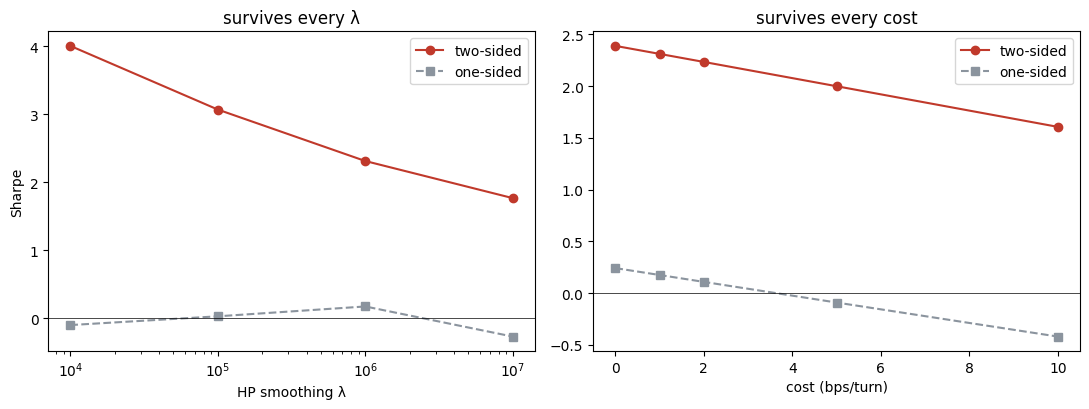

In [5]:
ls = extension.lam_sweep(close0); cs = extension.cost_robustness(close0)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(ls.index, ls['two_sided_sharpe'].values, 'o-', color='#c0392b', label='two-sided')
a1.plot(ls.index, ls['one_sided_sharpe'].values, 's--', color='#8b949e', label='one-sided')
a1.set_xscale('log'); a1.set_xlabel('HP smoothing λ'); a1.set_ylabel('Sharpe'); a1.axhline(0, c='k', lw=.5); a1.legend(); a1.set_title('survives every λ')
a2.plot(cs.index, cs['two_sided_sharpe'].values, 'o-', color='#c0392b', label='two-sided')
a2.plot(cs.index, cs['one_sided_sharpe'].values, 's--', color='#8b949e', label='one-sided')
a2.set_xlabel('cost (bps/turn)'); a2.axhline(0, c='k', lw=.5); a2.legend(); a2.set_title('survives every cost')
plt.tight_layout(); plt.show()

**The result.** On a random walk the two-sided book clears Sharpe ~1.5–2 at *every* λ and *every* cost, while the causal book hugs zero throughout. A researcher who only ran the usual checks — costs, parameter stability — would *validate* a strategy that is 100% artefact. The one check that matters is the one rarely run: recompute the signal causally. Full run in [`../docs/extension.md`](../docs/extension.md).

### 7b · Other forks
- **The leak museum.** Add other full-sample transforms (two-sided Butterworth, full-sample z-score, regression-on-all-data) and measure each leak the same way.
- **Causal HP via Kalman.** Replace the rolling-window endpoint with the Kalman-filtered local-linear-trend — smoother, still causal; does any edge appear? (We bet not.)
- **A linter.** Automate the perturbation test — bump a future point, flag any signal whose past values move — as a CI check for the whole repo.

PRs welcome — find a causal variant with a real edge, or extend the trap museum.